# Machine Learning 2025/2026

### Group no. 05 - David Silva no. 53755  / Luís Reis no. 64409 / Tiago Pereira no. 55854 

# ML Project  - Learning about Donations

## 0.3. Preprocessing Data

### Naive Bayes Binário (Target_B) - VERSÃO COM TRATAMENTO DE NULOS

### Doador vs Não-Doador

    Resultados fruto do desbalanceamento extremo (classe 0 dominante: ~79% dos dados).

### Resultados principais:
    Classe 0 (não-doador): precision 0.77, recall 0.87 → excelente a identificar não-doadores

    Classe 1 (doador): precision 0.37, recall 0.23 → conservador devido a poucos doadores (F1 baixo: 0.284)

    AUC ~0.61: alinhado com outros modelos, mas biased pelo desbalanceamento

### Melhoria com tratamento de nulos:
    TEST accuracy: 70.7% (+0pp vs anterior) | F1 classe 1: 0.284 (+0pp) | AUC: 0.610 (idêntico)

### Efeito ao ajustar threshold na classe 1 (default 0.5):
    Threshold	TEST Accuracy	F1 classe 1 (TEST)	Recall classe 1
      0.50	           0.707	       0.284	            0.233
      0.30	           0.655	       0.364	            0.395
      0.25	           0.632	       0.386	            0.462
    
    Threshold 0.25-0.30 preferível para priorizar detetar doadores (+10pp F1/recall, custo -7pp accuracy).

Naive Bayes (TARGET_B)
TRAIN accuracy = 0.7043155069172001
TEST  accuracy = 0.7069997935164154


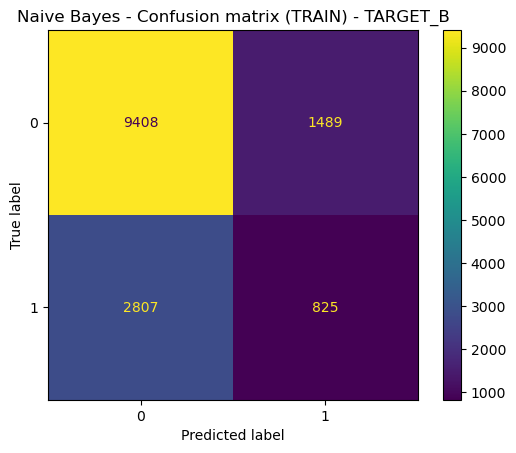

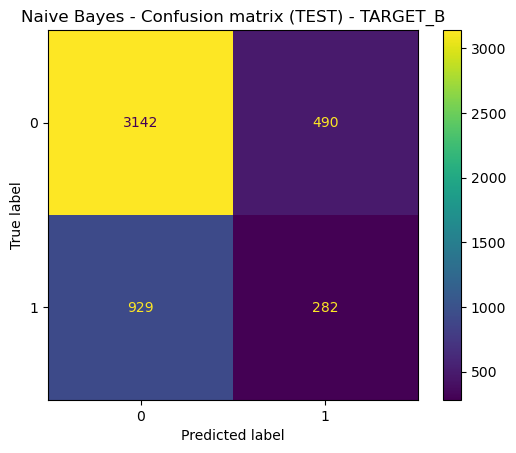


TRAIN classification report (Naive Bayes - TARGET_B):
              precision    recall  f1-score   support

           0     0.7702    0.8634    0.8141     10897
           1     0.3565    0.2271    0.2775      3632

    accuracy                         0.7043     14529
   macro avg     0.5634    0.5453    0.5458     14529
weighted avg     0.6668    0.7043    0.6800     14529

TEST classification report (Naive Bayes - TARGET_B):
              precision    recall  f1-score   support

           0     0.7718    0.8651    0.8158      3632
           1     0.3653    0.2329    0.2844      1211

    accuracy                         0.7070      4843
   macro avg     0.5685    0.5490    0.5501      4843
weighted avg     0.6702    0.7070    0.6829      4843

F1 (class 1) - TRAIN: 0.27749747729566093
F1 (class 1) - TEST : 0.2844175491679274
TEST AUC (Naive Bayes - TARGET_B) = 0.6103429193479739


In [5]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, roc_auc_score
)
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Ler dados
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

numeric_features = [
    "RECENT_AVG_GIFT_AMT", "LAST_GIFT_AMT", "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", "LIFETIME_MAX_GIFT_AMT", "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", "MONTHS_SINCE_FIRST_GIFT", "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", "WEALTH_RATING", "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", "RECENT_RESPONSE_COUNT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Manter TARGET_B + features
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputação de missing values

# Numéricas: mediana
for col in numeric_features:
    df_B[col + "_unknown"] = df_B[col].isna().astype(int)
    median_val = df_B[col].median()
    df_B[col] = df_B[col].fillna(median_val)
    
# Categóricas: se encontrar algum null, muda-o para "Unknown"
for col in categorical_features:
    df_B[col] = df_B[col].fillna("Unknown")

# 3. One-hot encoding para categóricas
df_B_encoded = pd.get_dummies(
    df_B,
    columns=categorical_features,
    drop_first=True
)

X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

X_train, X_test, y_train, y_test = train_test_split(
    X_B_full, y_B_full, random_state=42, stratify=y_B_full
)

# 4. Modelo Naive Bayes
nb_bin = GaussianNB()
nb_bin.fit(X_train, y_train)

# 5. Predições
y_train_pred = nb_bin.predict(X_train)
y_test_pred  = nb_bin.predict(X_test)

print("Naive Bayes (TARGET_B)")
print("TRAIN accuracy =", (y_train_pred == y_train).mean())
print("TEST  accuracy =", (y_test_pred == y_test).mean())

# 6. Matrizes de confusão
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(cm_train)
disp_train.plot()
plt.title("Naive Bayes - Confusion matrix (TRAIN) - TARGET_B")
plt.show()

cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(cm_test)
disp_test.plot()
plt.title("Naive Bayes - Confusion matrix (TEST) - TARGET_B")
plt.show()

# 7. Classification report + F1 da classe 1
print("\nTRAIN classification report (Naive Bayes - TARGET_B):")
print(classification_report(y_train, y_train_pred, digits=4))

print("TEST classification report (Naive Bayes - TARGET_B):")
print(classification_report(y_test, y_test_pred, digits=4))

f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test  = f1_score(y_test,  y_test_pred,  pos_label=1)
print("F1 (class 1) - TRAIN:", f1_train)
print("F1 (class 1) - TEST :", f1_test)

# 8. AUC binário
y_test_proba = nb_bin.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_test_proba)
print("TEST AUC (Naive Bayes - TARGET_B) =", auc_test)


# -------------------------------------------------------------------------------------------

### Naive Bayes Multiclasse (Donation_Type) - VERSÃO COM TRATAMENTO DE NULOS
    Para multiclasse, Naive Bayes é aceitável como baseline, mas inferior ao CatBoost (~64%).

### Resultados Principais:
    TRAIN accuracy = 0.559 | TEST accuracy = 0.537 (+0.004 vs anterior)

    Accuracy ~54%: melhor que acaso (20%), mas -11pp vs CatBoost
    F1 macro TEST: 0.510 (+0.004 vs anterior)
    AUC macro (OvR): 0.8255 | AUC macro (OvO): 0.8308 (próximo do CatBoost 0.86)

### Desempenho por classe (TEST):
    Classe	Support	Precision	Recall	  F1	 Observação
      A	  29	  0.444	         0.414	0.429	Poucos exemplos
      B	  353	  0.730	         0.422	0.535	  Razoável
      C	  238	  0.369	         0.643	0.469	Muitos falsos positivos
      D	  308	  0.503	         0.315	0.387	 Mais fraca
      E	  283	  0.643	         0.845	0.730	  Excelente
    
    Classe E dominante: recall 84% (mais frequente).
    Classe C inflacionada: recall alto (64%), mas precision baixa (37%) → excesso de falsos positivos.

### Conclusões finais do Naive Bayes
    Baseline simples/interpretável: fácil justificar resultados
    CatBoost superior: +11pp accuracy, +9pp F1 macro, explora melhor interações (menos "assunções" C, confusão mais equilibrada C/D/E)
    Tratamento de nulos: melhoria marginal (+0.4pp accuracy/test, +0.4pp F1 macro) → código mais robusto sem perda

Classes DONATION_TYPE: ['A', 'B', 'C', 'D', 'E']

Naive Bayes (DONATION_TYPE)
TRAIN accuracy = 0.5586453744493393
TEST  accuracy = 0.5367464905037159


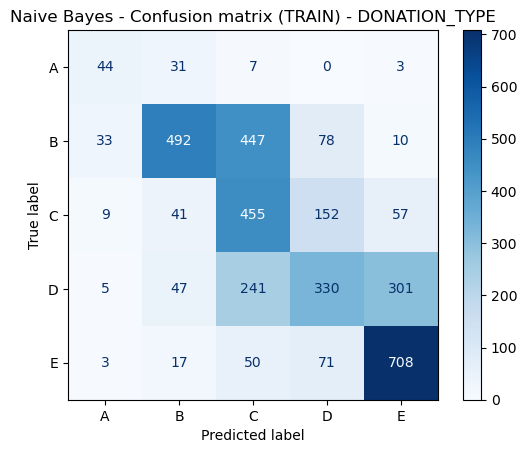

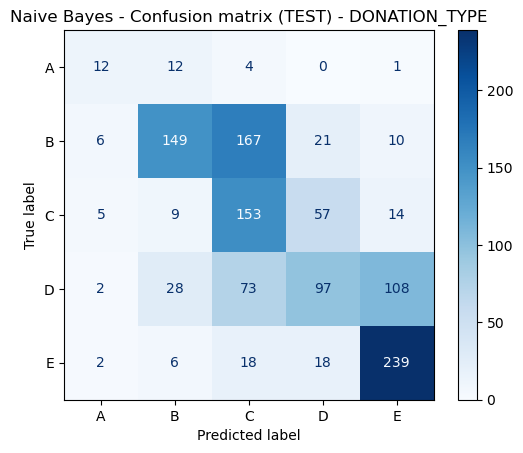


TRAIN classification report (Naive Bayes - DONATION_TYPE):
              precision    recall  f1-score   support

           A     0.4681    0.5176    0.4916        85
           B     0.7834    0.4642    0.5829      1060
           C     0.3792    0.6373    0.4754       714
           D     0.5230    0.3571    0.4244       924
           E     0.6562    0.8339    0.7344       849

    accuracy                         0.5586      3632
   macro avg     0.5620    0.5620    0.5418      3632
weighted avg     0.6006    0.5586    0.5548      3632

TEST classification report (Naive Bayes - DONATION_TYPE):
              precision    recall  f1-score   support

           A     0.4444    0.4138    0.4286        29
           B     0.7304    0.4221    0.5350       353
           C     0.3687    0.6429    0.4686       238
           D     0.5026    0.3149    0.3872       308
           E     0.6425    0.8445    0.7298       283

    accuracy                         0.5367      1211
   macro avg 

In [2]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, roc_auc_score
)
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Ler dados
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

numeric_features = [
    "RECENT_AVG_GIFT_AMT", "LAST_GIFT_AMT", "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", "LIFETIME_MAX_GIFT_AMT", "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", "MONTHS_SINCE_FIRST_GIFT", "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", "WEALTH_RATING", "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", "RECENT_RESPONSE_COUNT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

def donation_type(amount):
    if amount >= 50:
        return "A"
    elif 20 <= amount < 50:
        return "B"
    elif 13 <= amount < 20:
        return "C"
    elif 10 <= amount < 13:
        return "D"
    else:
        return "E"

# Ficar só com linhas onde TARGET_D não é null e criar DONATION_TYPE
df_cls_non_null = df_cls[df_cls["TARGET_D"].notnull()].copy()
df_cls_non_null["DONATION_TYPE"] = df_cls_non_null["TARGET_D"].apply(donation_type)

# Base para o modelo
df_D = df_cls_non_null[['DONATION_TYPE'] + numeric_features + categorical_features].copy()

# Imputação de missing values

# Numéricas: mediana
for col in numeric_features:
    df_D[col + "_unknown"] = df_D[col].isna().astype(int)
    median_val = df_D[col].median()
    df_D[col] = df_D[col].fillna(median_val)
    
# Categóricas: se encontrar algum null, muda-o para "Unknown"
for col in categorical_features:
    df_D[col] = df_D[col].fillna("Unknown")

# 3. One-hot encoding nas categóricas
df_D_encoded = pd.get_dummies(
    df_D,
    columns=categorical_features,
    drop_first=True
)

X_D_full = df_D_encoded.drop('DONATION_TYPE', axis=1)
y_D_full = df_D_encoded['DONATION_TYPE']    # ainda como string A–E

# Opcional: garantir encoding consistente de labels
labels = sorted(y_D_full.unique())
print("Classes DONATION_TYPE:", labels)

X_train, X_test, y_train, y_test = train_test_split(
    X_D_full, y_D_full, random_state=42, stratify=y_D_full
)

# 4. Modelo Naive Bayes multiclasse
nb_multi = GaussianNB()
nb_multi.fit(X_train, y_train)

# 5. Predições
y_train_pred = nb_multi.predict(X_train)
y_test_pred  = nb_multi.predict(X_test)

print("\nNaive Bayes (DONATION_TYPE)")
print("TRAIN accuracy =", (y_train_pred == y_train).mean())
print("TEST  accuracy =", (y_test_pred == y_test).mean())

# 6. Matrizes de confusão
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
disp_train = ConfusionMatrixDisplay(cm_train, display_labels=labels)
disp_train.plot(cmap='Blues')
plt.title("Naive Bayes - Confusion matrix (TRAIN) - DONATION_TYPE")
plt.show()

cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
disp_test = ConfusionMatrixDisplay(cm_test, display_labels=labels)
disp_test.plot(cmap='Blues')
plt.title("Naive Bayes - Confusion matrix (TEST) - DONATION_TYPE")
plt.show()

# 7. Classification reports + F1 macro
print("\nTRAIN classification report (Naive Bayes - DONATION_TYPE):")
print(classification_report(y_train, y_train_pred, digits=4))

print("TEST classification report (Naive Bayes - DONATION_TYPE):")
print(classification_report(y_test, y_test_pred, digits=4))

f1_train_macro = f1_score(y_train, y_train_pred, average='macro')
f1_test_macro  = f1_score(y_test,  y_test_pred,  average='macro')
print("F1 macro - TRAIN:", f1_train_macro)
print("F1 macro - TEST :", f1_test_macro)

# 8. AUC multiclasse (OvR / OvO)
y_test_proba = nb_multi.predict_proba(X_test)   # (n_samples, n_classes)

auc_macro_ovr = roc_auc_score(
    y_test,
    y_test_proba,
    multi_class='ovr',
    average='macro'
)
print(f"AUC macro (OvR) - DONATION_TYPE (Naive Bayes): {auc_macro_ovr:.4f}")

auc_macro_ovo = roc_auc_score(
    y_test,
    y_test_proba,
    multi_class='ovo',
    average='macro'
)
print(f"AUC macro (OvO) - DONATION_TYPE (Naive Bayes): {auc_macro_ovo:.4f}")


## Task 1 (Supervised Learning) - Predicting Donation and Donation Type

In this task you should target 2 classification tasks:
1. **Predicting Donation (binary classification task)** 
2. **Predicting Donation TYPE (multiclass classification)**

**You should:**

* Choose **5 classifiers** from **at least 3 of the following categories**: Tree models, Probabilistic models, Distance-based models and Linear models. You can also try one Ensemble Classifier (https://scikit-learn.org/1.5/modules/ensemble.html). 
* Use **cross-validation** to evaluate the results.
* Describe the parameters used for each classifier and how their choice impacted or not the results.
* Choose the **best classifier** and fundament you choice.
* Present and discuss the results for different evaluation measures, present confusion matrices. Remember that not only overall results are important. Check what happens when learning to predict each class. Remember also that some metrics might be more adequate than others according to the problem at hand.

* **Discuss critically your choices and the results!**

## 1.1. Specific Data Preprocessing for Classification

## 1.2. Learning and Evaluating Classifiers

...

## 1.3. Classification - Final Discussion and Conclusions 

...

## Task 2 (Unsupervised Learning) - Characterizing Donors and Donation Type

In this task you should **use unsupervised learning to characterize donors (people who really did a donation) and their donation type**.
1. **Use clustering algorithms to find similar groups of donors**. Is it possible to find groups of donors with the same/similar DonationTYPE? Evaluate clustering results using **internal and external metrics**.
2. **Be creative and define and explore your own clustering task!** What else would it be interesting to find out?

## 2.1. Preprocessing Data for Clustering

...

## 2.2. Learning and Evaluating Clusterings

...

## 2.3. Clustering - Final Discussion and Conclusions

...

## 3. Final Comments and Conclusions

...